# Data Preprocessing and Feature Engineering
### Interactive Notebook for AI/ML Interview Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
sns.set_style('whitegrid')
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Handling Missing Data

In [2]:
# Create dataset with missing values
n = 200
df = pd.DataFrame({
    'age': np.random.normal(35, 10, n),
    'salary': np.random.normal(60000, 15000, n),
    'category': np.random.choice(['A','B','C'], n)
})
# Inject missing values
df.loc[np.random.choice(n, 30, replace=False), 'age'] = np.nan
df.loc[np.random.choice(n, 20, replace=False), 'salary'] = np.nan

print('Missing values:')
print(df.isnull().sum())

# Compare imputation strategies
for strategy in ['mean', 'median']:
    imp = SimpleImputer(strategy=strategy)
    filled = imp.fit_transform(df[['age', 'salary']])
    print(f'\n{strategy.upper()} imputation — age mean: {filled[:,0].mean():.1f}')

Missing values:
age         30
salary      20
category     0
dtype: int64

MEAN imputation — age mean: 34.1

MEDIAN imputation — age mean: 34.1


---
## 2. Feature Scaling

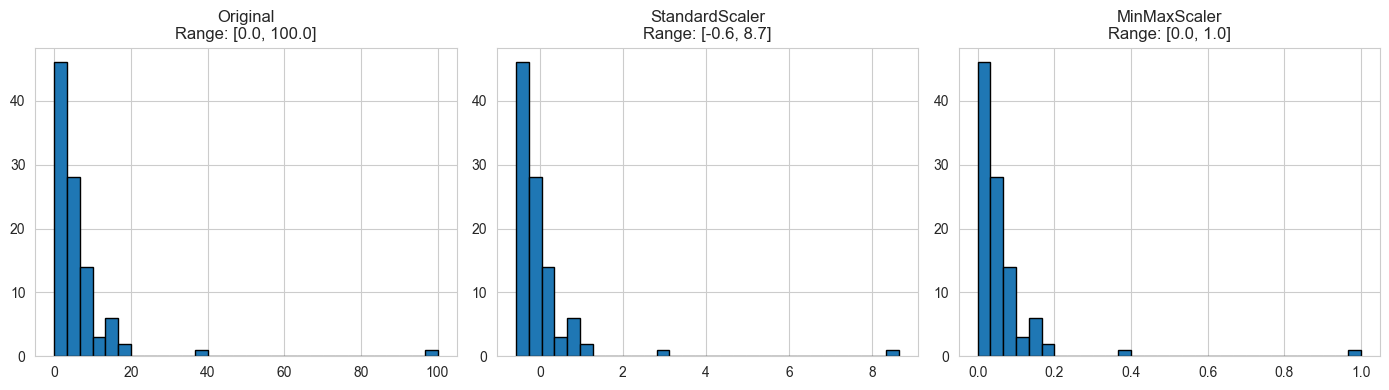

In [3]:
# Compare scalers
data = np.random.exponential(5, (100, 1))  # skewed data
data = np.vstack([data, [[100]]])  # add outlier

scalers = {
    'Original': data,
    'StandardScaler': StandardScaler().fit_transform(data),
    'MinMaxScaler': MinMaxScaler().fit_transform(data),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, d) in zip(axes, scalers.items()):
    ax.hist(d, bins=30, edgecolor='black')
    ax.set_title(f'{name}\nRange: [{d.min():.1f}, {d.max():.1f}]')
plt.tight_layout(); plt.show()

---
## 3. Encoding Categorical Variables

In [4]:
categories = ['low', 'medium', 'high', 'low', 'high', 'medium']

# Label encoding
le = LabelEncoder()
label_encoded = le.fit_transform(categories)
print(f'Label encoded: {dict(zip(categories, label_encoded))}')

# One-hot encoding
ohe = OneHotEncoder(sparse_output=False)
onehot = ohe.fit_transform(np.array(categories).reshape(-1, 1))
print(f'\nOne-hot encoded (first 3 rows):\n{onehot[:3]}')
print(f'Feature names: {ohe.categories_[0].tolist()}')
print('\nInterview tip: Use one-hot for nominal (no order), label for ordinal, target encoding for high cardinality')

Label encoded: {'low': np.int64(1), 'medium': np.int64(2), 'high': np.int64(0)}

One-hot encoded (first 3 rows):
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
Feature names: ['high', 'low', 'medium']

Interview tip: Use one-hot for nominal (no order), label for ordinal, target encoding for high cardinality


---
## 4. Outlier Detection

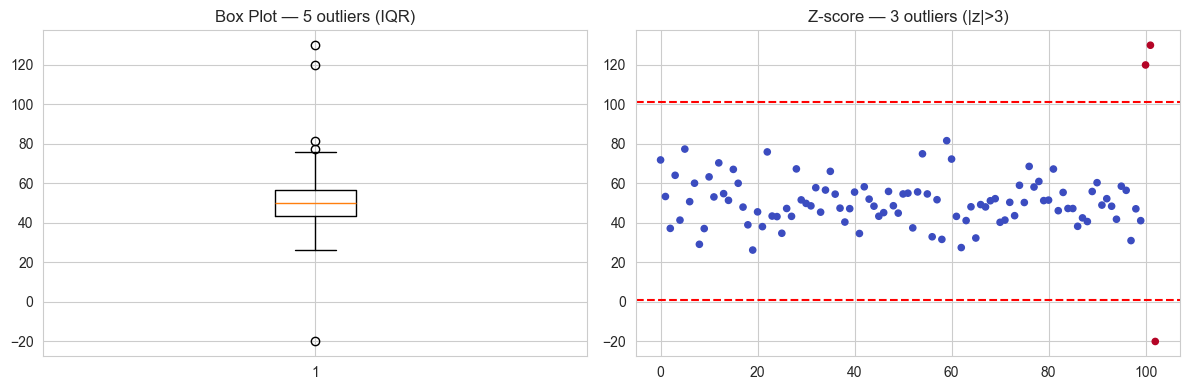

In [5]:
data = np.concatenate([np.random.normal(50, 10, 100), [120, 130, -20]])

# IQR method
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers_iqr = data[(data < lower) | (data > upper)]

# Z-score method
z_scores = np.abs((data - data.mean()) / data.std())
outliers_z = data[z_scores > 3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(data); axes[0].set_title(f'Box Plot — {len(outliers_iqr)} outliers (IQR)')
axes[1].scatter(range(len(data)), data, c=z_scores > 3, cmap='coolwarm', s=20)
axes[1].axhline(y=data.mean()+3*data.std(), color='r', linestyle='--')
axes[1].axhline(y=data.mean()-3*data.std(), color='r', linestyle='--')
axes[1].set_title(f'Z-score — {len(outliers_z)} outliers (|z|>3)')
plt.tight_layout(); plt.show()

---
## 5. Data Leakage — The Critical Pitfall

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = np.random.randn(200, 5)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# WRONG: scale before split (leaks test info into training)
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)  # fit on ALL data
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled_wrong, y, test_size=0.3, random_state=42)
clf = LogisticRegression().fit(X_tr, y_tr)
acc_wrong = accuracy_score(y_te, clf.predict(X_te))

# RIGHT: scale after split
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.3, random_state=42)
scaler_right = StandardScaler()
X_tr2 = scaler_right.fit_transform(X_tr2)  # fit on train only
X_te2 = scaler_right.transform(X_te2)       # transform test
clf2 = LogisticRegression().fit(X_tr2, y_tr2)
acc_right = accuracy_score(y_te2, clf2.predict(X_te2))

print(f'With leakage:    {acc_wrong:.1%}')
print(f'Without leakage: {acc_right:.1%}')
print('Data leakage makes results look better than they really are!')

With leakage:    95.0%
Without leakage: 95.0%
Data leakage makes results look better than they really are!


---
## Key Interview Takeaways

1. **Missing data** — understand MCAR/MAR/MNAR; mean imputation is simplest, not always best
2. **Scaling** — StandardScaler for normal data, RobustScaler with outliers, MinMax for bounded
3. **Encoding** — one-hot for nominal, ordinal for ordered, target encoding for high cardinality
4. **Data leakage** — always fit scalers/encoders on training data ONLY
5. **Outliers** — IQR and Z-score are most common detection methods